<a href="https://colab.research.google.com/github/bhausaheb-pachaptil/Basics-of-Python-/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Bhausaheb Pachpatil MIS No:712566006
Title:Spam or Ham (Not Spam) using NLP techniques

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset


In [5]:
import pandas as pd
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import os

# Construct the full path to the dataset file
dataset_file_path = os.path.join(path, 'spam.csv')

# Load dataset
df = pd.read_csv(dataset_file_path, encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Display the first few rows of the DataFrame
print('Dataset loaded successfully:')
display(df.head())

# Display basic information about the DataFrame
print('\nDataFrame Info:')
display(df.info())

# Display the distribution of labels
print('\nLabel Distribution:')
display(df['label'].value_counts())

Dataset loaded successfully:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


None


Label Distribution:


,count
label,
ham,4825
spam,747


### Data Preprocessing

This section cleans the text data and converts the labels into a binary format (0 for 'ham', 1 for 'spam').

In [6]:
# Convert labels to binary
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    return text

df['message'] = df['message'].apply(clean_text)

print('Cleaned messages and converted labels:')
display(df.head())

Cleaned messages and converted labels:


,label,message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...


### Model Training and Evaluation

Here, the data is split into training and testing sets, text messages are converted into numerical features using TF-IDF, and a Multinomial Naive Bayes classifier is trained and evaluated.

In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(df['message'], df['label'], test_size=0.2, random_state=42)

print(f'Training set size: {len(X_train)} samples')
print(f'Testing set size: {len(X_test)} samples')

# Convert text to vectors
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print('\nText vectorized using TF-IDF.')

# Train model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

print('\nMultinomial Naive Bayes model trained.')

# Prediction
y_pred = model.predict(X_test_vec)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'\nModel Accuracy: {accuracy:.4f}')

Training set size: 4457 samples
Testing set size: 1115 samples

Text vectorized using TF-IDF.

Multinomial Naive Bayes model trained.

Model Accuracy: 0.9543



Confusion Matrix:
[[965   0]
 [ 51  99]]


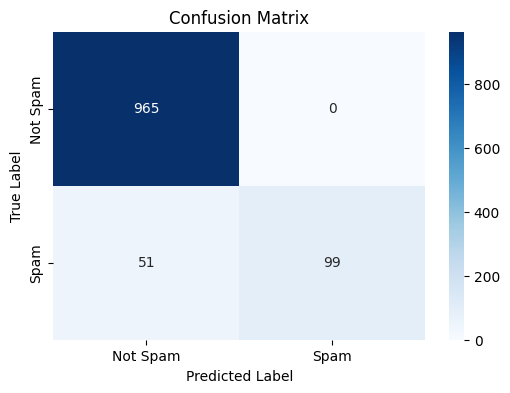


Precision: 1.0000
Recall: 0.6600
F1-Score: 0.7952


In [8]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f'\nConfusion Matrix:\n{cm}')

# Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'\nPrecision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

### Test with Custom Message

Finally, let's test the trained model with a custom message to see if it correctly identifies it as 'spam' or 'not spam'.

Name: Bhausaheb Pachpatil MIS No:712566006
Title:Spam or Ham (Not Spam) using NLP techniques

In [9]:
# Test with custom messages
custom_messages = [
    "Congratulations! You won a free ticket to the Bahamas. Text WIN to 1234 for details.",
    "Hey, just checking in to see how you're doing. Call me later.",
    "URGENT! Your bank account has been compromised. Click this link to verify your identity: http://malicious-link.com"
]

for msg in custom_messages:
    cleaned_msg = clean_text(msg)
    msg_vec = vectorizer.transform([cleaned_msg])
    prediction = model.predict(msg_vec)[0]
    status = "Spam" if prediction == 1 else "Not Spam"
    print(f'\nMessage: "{msg}"')
    print(f'Prediction: {status}')


Message: "Congratulations! You won a free ticket to the Bahamas. Text WIN to 1234 for details."
Prediction: Spam

Message: "Hey, just checking in to see how you're doing. Call me later."
Prediction: Not Spam

Message: "URGENT! Your bank account has been compromised. Click this link to verify your identity: http://malicious-link.com"
Prediction: Not Spam
